# 🔍 Playground · Interpretabilidad (SHAP)
---

> ⚠️ Este notebook es **autónomo**: **no** importa nada de `src/`. Todo el código vive aquí, igual que en los notebooks de `recursos/`. No es la fuente de verdad del proyecto, sino un cuaderno de exploración: lo que de verdad usa el servicio ya está en `src/`, esto es lo que aprendimos practicando aquí.

### Objetivo
Un buen modelo no solo tiene que **acertar**: además debería ser **explicable**. La *interpretabilidad* responde a la pregunta "¿**por qué** el modelo ha predicho esto?". Es clave para:

- **Confiar** en el modelo y detectar sesgos o fugas de información.
- **Comunicar** los resultados a personas de negocio.
- **Actuar**: si sabemos qué empuja a una cancelación, podemos intervenir.

Aquí explicamos un **XGBoost** entrenado sobre las reservas hoteleras con dos herramientas complementarias:

1. **SHAP** (*SHapley Additive exPlanations*) — explicaciones globales y locales.
2. **Importancia por permutación** — cuánto se degrada el modelo al "romper" cada variable.

### Información útil
+ [Documentación oficial de SHAP](https://shap.readthedocs.io/)
+ [Permutation importance (scikit-learn)](https://scikit-learn.org/stable/modules/permutation_importance.html)
+ [Documentación oficial XGBoost](https://xgboost.readthedocs.io/)

## 0. Configuración del Notebook
Importamos todas las librerías de golpe para tenerlas controladas en un único sitio.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import warnings; warnings.filterwarnings('ignore')
import shap
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

### Definición de constantes

In [2]:
# Datasets YA procesados por el notebook 02 (train/test separados, fit-on-train)
PATH_DIRECTORIO_DATOS = "../../data/processed"
PATH_TRAIN = f"{PATH_DIRECTORIO_DATOS}/train.csv"
PATH_TEST = f"{PATH_DIRECTORIO_DATOS}/test.csv"

# Columna objetivo y nombres legibles de las clases
target_column = 'is_canceled'
list_nombres_clases = ['No cancelada', 'Cancelada']
dict_target_hotel = {0: 'No cancelada', 1: 'Cancelada'}

RANDOM_STATE = 42

## 1. Datos y modelo

Partimos del dataset que preparó [`02_preparacion_datos.ipynb`](02_preparacion_datos.ipynb): ya viene **limpio, codificado (*one-hot*) y separado en `train`/`test`** (preprocesado *fit-on-train*). Cargamos esos ficheros y entrenamos sobre ellos el **XGBoost** que vamos a explicar — el mismo modelo del notebook `03`/`05`.

In [3]:
# Cargamos el dataset ya procesado (features one-hot + objetivo)
train_df = pd.read_csv(PATH_TRAIN)
test_df = pd.read_csv(PATH_TEST)

X_train = train_df.drop(columns=target_column)
y_train = train_df[target_column]
X_test = test_df.drop(columns=target_column)
y_test = test_df[target_column]
assert list(X_train.columns) == list(X_test.columns), "Columnas train/test no coinciden"

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (94850, 144) | Test: (23713, 144)


In [4]:
# Entrenamos el XGBoost que vamos a explicar
modelo = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
modelo.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [5]:
# Comprobamos que el modelo es bueno antes de explicarlo
from sklearn.metrics import roc_auc_score

y_proba = modelo.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC en test: {roc_auc:.4f}")

ROC-AUC en test: 0.9435


## 2. SHAP — ¿qué es?
**SHAP** (*SHapley Additive exPlanations*) se basa en los **valores de Shapley** de la teoría de juegos: reparte la predicción del modelo **entre todas las variables**, de forma justa, asignando a cada una cuánto ha empujado la predicción hacia "cancela" (valores positivos) o hacia "no cancela" (valores negativos).

La gran ventaja: sirve tanto para una **visión global** (qué variables importan en todo el dataset) como para explicar una **predicción individual**. Para modelos de árboles como XGBoost existe `TreeExplainer`, que calcula los valores SHAP de forma **exacta y eficiente**.

> Nota: las gráficas propias de SHAP son de **matplotlib** (no plotly). Las dejamos así porque son el estándar de la librería.

In [6]:
# --- Parche puntual SHAP + XGBoost >= 2.x ---
# XGBoost 2.x serializa 'base_score' como cadena entre corchetes (p. ej. '[3.7E-1]')
# y SHAP 0.49 hace float(base_score) directamente -> ValueError. Limpiamos los
# corchetes envolviendo el decodificador UBJ que usa SHAP, antes de que lo lea.
import shap.explainers._tree as _shap_tree
if not getattr(_shap_tree, "_pontia_base_score_patched", False):
    _orig_decode = _shap_tree.decode_ubjson_buffer
    def _decode_and_fix(fd):
        jm = _orig_decode(fd)
        learner = jm.get("learner") if isinstance(jm, dict) else None
        params = learner.get("learner_model_param") if isinstance(learner, dict) else None
        bs = params.get("base_score") if isinstance(params, dict) else None
        if isinstance(bs, str) and bs.startswith("[") and bs.endswith("]"):
            params["base_score"] = bs.strip("[]")
        return jm
    _shap_tree.decode_ubjson_buffer = _decode_and_fix
    _shap_tree._pontia_base_score_patched = True

In [7]:
# Construimos el explainer para modelos de árboles (exacto y rápido)
explainer = shap.TreeExplainer(modelo)

# SHAP es costoso, así que trabajamos sobre una submuestra reproducible del test
X_shap = X_test.sample(n=2000, random_state=RANDOM_STATE)

# Valores SHAP: matriz (n_filas x n_variables), uno por cada (fila, variable)
shap_values = explainer.shap_values(X_shap)
print('shape de shap_values:', np.asarray(shap_values).shape)

shape de shap_values: (2000, 144)


## 3. Importancia global de variables (barra)
El resumen más directo: la **media del valor absoluto** de SHAP por variable. Cuanto más alta, más peso tiene esa variable en las predicciones del modelo (en conjunto).

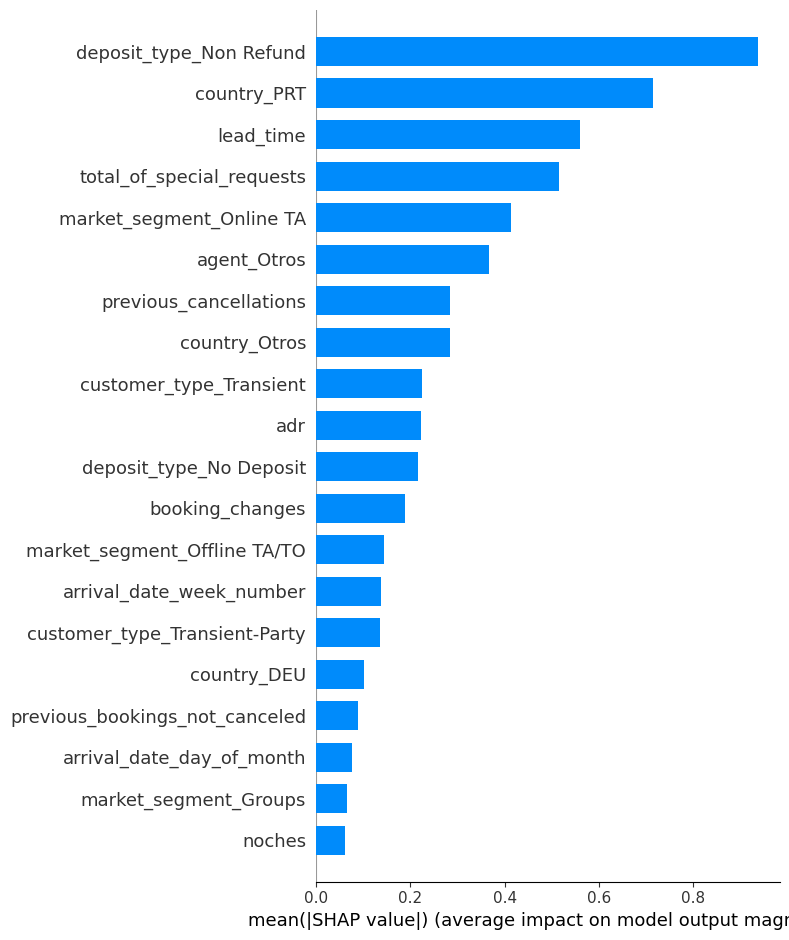

In [8]:
# Importancia global = media |SHAP| por variable (gráfico de SHAP, matplotlib)
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

**Lectura.** Arriba aparecen los grandes *drivers*: las columnas *dummy* de `deposit_type_Non Refund`, `lead_time`, varias de `country_*` y `total_of_special_requests`. Coincide con lo que vimos en el EDA: el depósito no reembolsable y la antelación son los que mandan.

## 4. Gráfico *beeswarm* (enjambre)
El *beeswarm* es más rico que la barra: cada punto es **una reserva**.

- **Eje X**: valor SHAP → a la derecha empuja hacia **cancelar**, a la izquierda hacia **no cancelar**.
- **Color**: valor de la variable (rojo = alto, azul = bajo).

Así vemos no solo *cuánto* importa una variable, sino *en qué dirección*: por ejemplo, si los `lead_time` altos (rojos) se acumulan a la derecha, significa que **más antelación → más probabilidad de cancelación**.

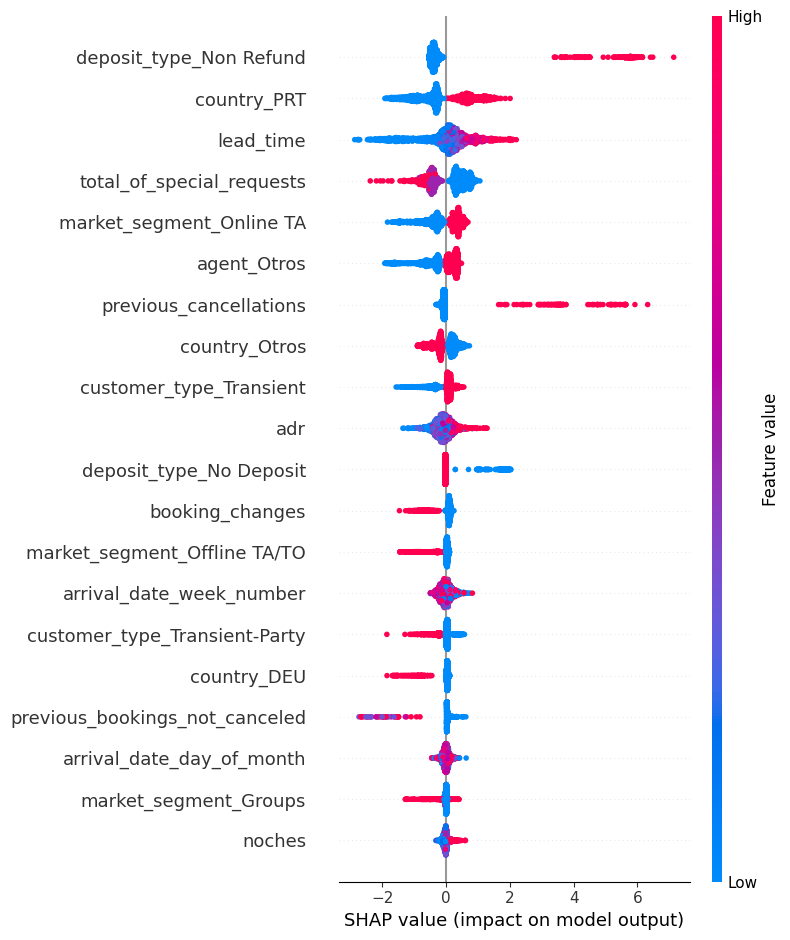

In [9]:
# Beeswarm: distribución de los valores SHAP por variable (matplotlib)
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.show()

**Lectura.** En `lead_time` los puntos rojos (valores altos) caen a la derecha: reservar con mucha antelación empuja a cancelar. En `total_of_special_requests` ocurre lo contrario: más peticiones especiales (rojo) empujan a la izquierda, es decir, hacia **no** cancelar (clientes más comprometidos).

## 5. Explicación local: gráfico *waterfall*
Hasta ahora hemos visto el modelo "en conjunto". El *waterfall* explica **una sola predicción**: parte del valor base (la predicción media del modelo) y va sumando la contribución de cada variable hasta llegar a la predicción final de **esa** reserva.

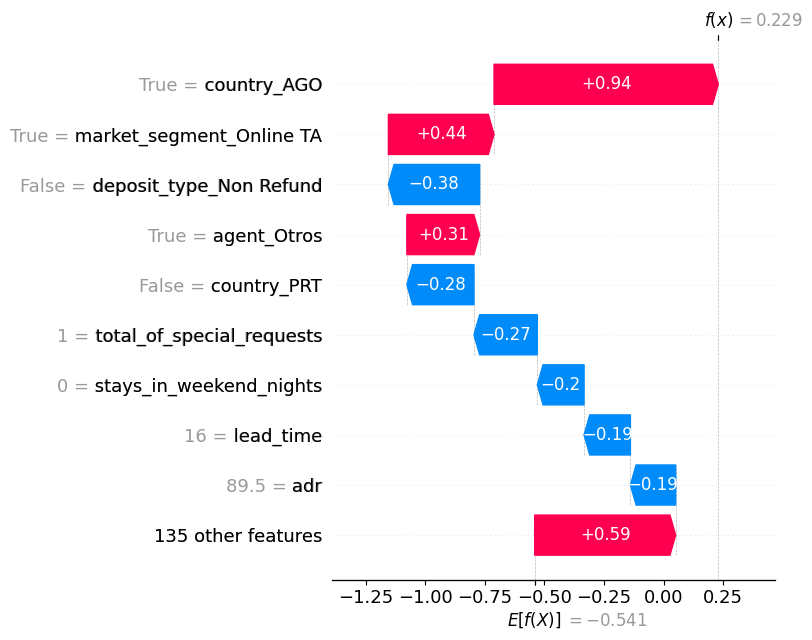

In [10]:
# Elegimos una reserva concreta de la submuestra
i = 0
expl = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_shap.iloc[i],
    feature_names=X_shap.columns.tolist(),
)

shap.plots.waterfall(expl, show=False)
plt.tight_layout()
plt.show()

**Lectura.** Las barras rojas empujan la predicción hacia **cancelar** y las azules hacia **no cancelar**. La suma de todas, partiendo del valor base `E[f(x)]`, da la predicción (en *log-odds*) para esta reserva concreta. Es la forma de justificar, caso por caso, **por qué** el modelo marca una reserva como de riesgo.

## 6. Importancia por permutación
Otra mirada, **independiente del modelo** (*model-agnostic*): barajamos al azar los valores de una variable y medimos **cuánto empeora** la métrica (aquí, ROC-AUC). Si romper una variable hunde el rendimiento, es que el modelo dependía mucho de ella.

Es más caro de calcular (reentrena la evaluación muchas veces), así que lo hacemos sobre una submuestra del test.

In [11]:
# Submuestra para acotar el tiempo de cómputo
X_perm = X_test.sample(n=3000, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

result = permutation_importance(
    modelo, X_perm, y_perm,
    scoring='roc_auc',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [12]:
# Montamos un DataFrame con la importancia media y nos quedamos con el top 15
df_perm = pd.DataFrame({
    'variable': X_perm.columns,
    'importancia': result.importances_mean,
})
df_perm = df_perm.sort_values(by='importancia', ascending=False).head(15)
df_perm = df_perm.sort_values(by='importancia', ascending=True)
df_perm

,variable,importancia
11,booking_changes,0.005214
10,previous_bookings_not_canceled,0.006093
41,market_segment_Groups,0.006789
1,arrival_date_week_number,0.007819
78,country_Otros,0.008604
59,deposit_type_No Deposit,0.009409
64,customer_type_Transient,0.014785
13,adr,0.016099
9,previous_cancellations,0.030818
14,total_of_special_requests,0.034738


In [13]:
# Visualización con plotly (horizontal, top 15)
fig = px.bar(
    df_perm,
    x='importancia',
    y='variable',
    orientation='h',
    title='Importancia por permutación (caída de ROC-AUC) · Top 15',
    labels={'importancia': 'Caída media de ROC-AUC', 'variable': 'Variable'},
    width=800, height=600,
)
fig.show(renderer='notebook_connected')

**Lectura.** La permutación confirma a SHAP: `deposit_type_Non Refund` y `lead_time` son, con diferencia, los que más degradan el modelo al romperlos. Dos métodos distintos llegando a la misma conclusión dan **confianza** en la explicación.

## 7. Conclusiones
- **SHAP** nos da una explicación **completa**: importancia global (barra), dirección del efecto (*beeswarm*) y justificación caso a caso (*waterfall*).
- La **importancia por permutación**, calculada de forma totalmente distinta, **coincide** con SHAP: cuando dos métodos independientes concuerdan, podemos confiar más en la explicación.
- Ambos coinciden, además, con la **EDA**: los grandes *drivers* de la cancelación son `deposit_type_Non Refund`, `lead_time`, `country_*`, `total_of_special_requests`, etc.
- Conclusión práctica: el XGBoost no es una "caja negra". Sabemos **por qué** predice lo que predice, lo que lo hace utilizable y defendible ante negocio.